# Mode 1 vs Mode 2 on Towradgi small — where do the runs differ?

ANUGA can evolve the shallow-water equations two ways:

* **mode 1 (`legacy`)** — the original CPU solver (`set_multiprocessor_mode(1)`), and
* **mode 2 (`unified`)** — the unified C kernels that also drive GPU offload
  (`set_multiprocessor_mode(2)`, here with `-go`).

They implement the *same* equations but are not bit-identical: the two code paths sum
fluxes and apply updates in a different order, so they differ at floating-point roundoff on
the first step. In a wetting/drying flood model that roundoff is then **amplified
chaotically**, so by the end of a run the two solutions differ by a small but visible amount.

This notebook shows **where and when** that difference appears on the Towradgi historic-flood
small case (~256k triangles, `run_small_towradgi.py`, `finaltime = 3600 s`). The differences
are physically equivalent — they sit at the same magnitude as swapping GPU back ends
(OpenMP-target vs OpenACC) — but seeing their spatial structure is instructive: they
concentrate exactly where the flow is most active.

In [1]:
import os, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import anuga

# Run this notebook from the towradgi case directory.
HERE = os.getcwd()
OUT  = os.path.join(HERE, 'MODEL_OUTPUTS')
FT   = 3600                      # finaltime (s); the canonical small run
SWW1 = os.path.join(OUT, 'towradgi_mode1.sww')   # mode 1 (legacy CPU)
SWW2 = os.path.join(OUT, 'towradgi_mode2.sww')   # mode 2 (unified / GPU offload)

## 1. Generate the two runs (skipped if the `.sww` files already exist)

Each run stores its own `.sww`. Mode 1 uses CPU OpenMP threads; mode 2 offloads with `-go`
(on a CPU-only build `-go` is a no-op and mode 2 runs as unified CPU multicore, so the
notebook still works — it just won't be a GPU run). Regenerating both takes a few minutes.

In [2]:
def generate(mode, sww_path):
    if os.path.exists(sww_path):
        print(f'  {os.path.basename(sww_path)} exists — skipping')
        return
    env = dict(os.environ)
    args = ['python', 'run_small_towradgi.py', '-mpm', str(mode), '-ft', str(FT)]
    if mode == 1:
        env['OMP_NUM_THREADS'] = env.get('OMP_NUM_THREADS', '16')  # threaded CPU solver
    else:
        env['OMP_NUM_THREADS'] = '1'
        args.append('-go')                                         # GPU offload
    print(f'  running mode {mode} ...', flush=True)
    subprocess.run(args, cwd=HERE, env=env, check=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    # run_small_towradgi.py always writes this name; copy it aside
    import shutil
    shutil.copy(os.path.join(OUT, 'Towradgi_historic_flood.sww'), sww_path)
    print(f'  wrote {os.path.basename(sww_path)}')

generate(1, SWW1)
generate(2, SWW2)

  towradgi_mode1.sww exists — skipping
  towradgi_mode2.sww exists — skipping


## 2. Load both with `anuga.SWW_plotter`

`SWW_plotter` gives a matplotlib triangulation (`.triang`) plus each quantity as a
`(n_timesteps, n_triangles)` array of centroid values, which we plot with
`tripcolor(..., facecolors=...)`.

In [3]:
m1 = anuga.SWW_plotter(SWW1)   # mode 1
m2 = anuga.SWW_plotter(SWW2)   # mode 2

assert np.array_equal(m1.x, m2.x) and np.array_equal(m1.y, m2.y), 'meshes differ'
assert np.array_equal(m1.time, m2.time), 'time vectors differ'
n_tri = m1.triangles.shape[0]
print(f'{n_tri:,} triangles, {len(m1.time)} output times (0 .. {m1.time[-1]:.0f} s)')

# The quantities we compare. depth = stage - elevation; speed = |(u,v)|.
QUANTITIES = [('stage', 'stage',        'm'),
              ('xmom',  'x-momentum',   'm$^2$/s'),
              ('ymom',  'y-momentum',   'm$^2$/s'),
              ('depth', 'depth',        'm'),
              ('speed', 'speed',        'm/s')]

256,688 triangles, 31 output times (0 .. 3600 s)


## 3. When do the differences grow?

Maximum and RMS of `|mode 1 − mode 2|` over the domain at each output time. The differences
start at roundoff and amplify. Watch the **knee near t = 360 s**: that is when the rainfall
forcing steps up ~3.5×, wetting more cells and accelerating the chaotic amplification.

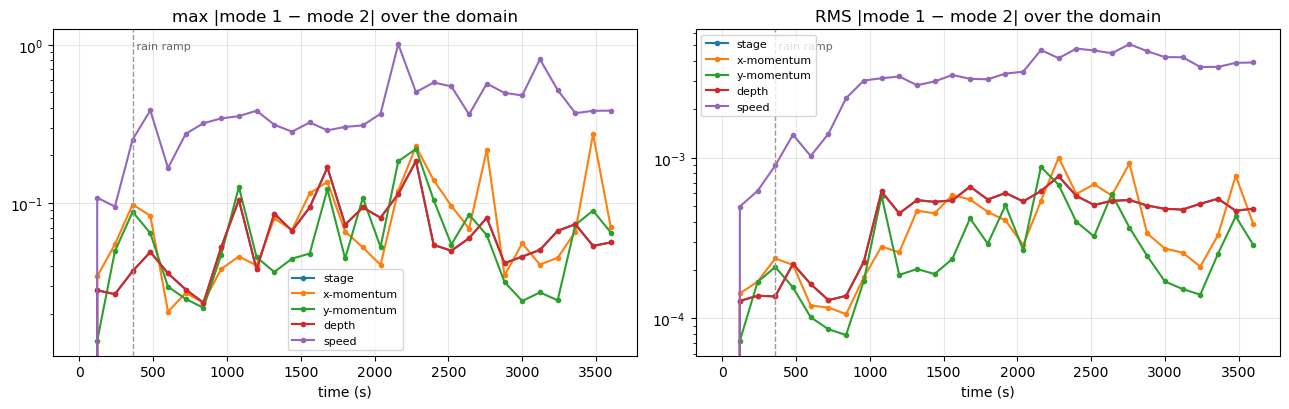

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
for key, label, _ in QUANTITIES:
    d = np.abs(getattr(m1, key) - getattr(m2, key))
    ax[0].plot(m1.time, d.max(axis=1), marker='.', label=label)
    ax[1].plot(m1.time, np.sqrt((d**2).mean(axis=1)), marker='.', label=label)
for a, t in zip(ax, ['max', 'RMS']):
    a.axvline(360, color='0.6', ls='--', lw=1)
    a.text(360, a.get_ylim()[1], ' rain ramp', color='0.4', va='top', fontsize=8)
    a.set_yscale('log'); a.set_xlabel('time (s)'); a.grid(alpha=.3)
    a.set_title(f'{t} |mode 1 − mode 2| over the domain')
    a.legend(fontsize=8)
fig.tight_layout()

## 4. Where are the differences? (final time)

Left: the mode-1 **flood depth** for context. Middle/right: `|Δstage|` and `|Δspeed|`, on a
**white → red intensity** scale (`YlOrRd`, log) with cells **below the noise floor masked out**
(|Δstage| < 1e-6 m, |Δspeed| < 1e-5 m/s), so the background is blank white where the two
solvers agree. Colour then marks *where* they actually diverge — the flooded channels, wet/dry
fronts and the culvert/inlet structures — with intensity growing toward the ~cm-scale peaks.

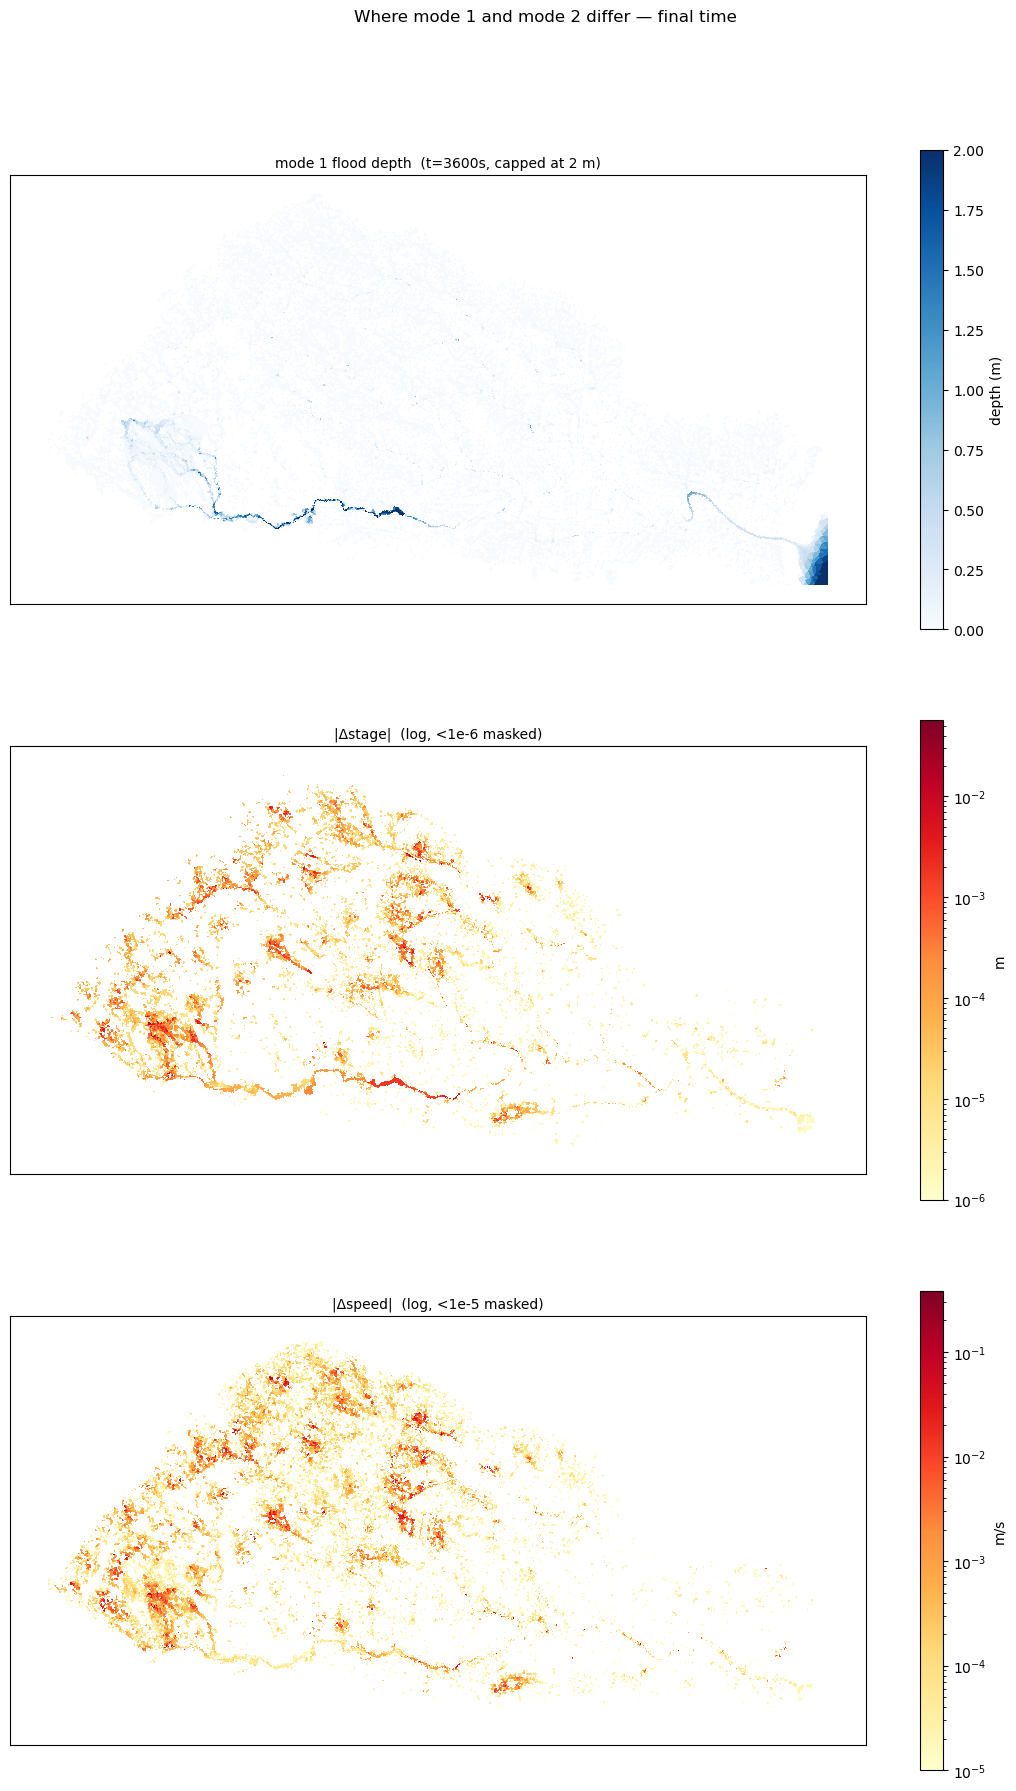

In [5]:
import matplotlib as mpl

def wet_mask(plotter, t_idx, thresh=1e-3):
    return plotter.depth[t_idx] > thresh

def _white_cmap(name):
    cm = mpl.colormaps[name].copy()
    cm.set_bad('white')          # masked / dry cells -> white background
    return cm

def diff_map(ax, values, title, cmap, label, norm=None, mask=None):
    m1.triang.set_mask(None)
    v = np.array(values, dtype=float)
    if mask is not None:
        v = np.where(mask, v, np.nan)
    ax.set_facecolor('white')
    kw = dict(norm=norm) if norm is not None else {}
    tpc = ax.tripcolor(m1.triang, facecolors=v, cmap=cmap, shading='flat', **kw)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    plt.colorbar(tpc, ax=ax, shrink=0.8, label=label)

def diff_only(plotter1, plotter2, key, t_idx, floor):
    """|q1 - q2| at t_idx, shown only where wet AND above the noise floor (else NaN)."""
    d = np.abs(getattr(plotter1, key)[t_idx] - getattr(plotter2, key)[t_idx])
    keep = wet_mask(plotter1, t_idx) & (d >= floor)
    return np.where(keep, d, np.nan), d[keep].max() if keep.any() else floor

i = -1
STAGE_FLOOR, SPEED_FLOOR = 1e-6, 1e-5
dstage, smax = diff_only(m1, m2, 'stage', i, STAGE_FLOOR)
dspeed, vmax = diff_only(m1, m2, 'speed', i, SPEED_FLOOR)

fig, ax = plt.subplots(3, 1, figsize=(11, 18)); fig.set_facecolor('white')
diff_map(ax[0], np.where(wet_mask(m1, i), m1.depth[i], np.nan),
         f'mode 1 flood depth  (t={m1.time[i]:.0f}s, capped at 2 m)', _white_cmap('Blues'),
         'depth (m)', norm=mpl.colors.Normalize(vmin=0, vmax=2, clip=True))
diff_map(ax[1], dstage, '|Δstage|  (log, <1e-6 masked)', _white_cmap('YlOrRd'), 'm',
         norm=LogNorm(vmin=STAGE_FLOOR, vmax=smax, clip=True))
diff_map(ax[2], dspeed, '|Δspeed|  (log, <1e-5 masked)', _white_cmap('YlOrRd'), 'm/s',
         norm=LogNorm(vmin=SPEED_FLOOR, vmax=vmax, clip=True))
fig.suptitle('Where mode 1 and mode 2 differ — final time', y=1.02)
fig.tight_layout()

## 5. How the spatial difference develops

`|Δstage|` (wet cells) at three times. Early on the difference is negligible and localised;
after the rain ramp it spreads through the flooded network but stays at the centimetre
level.

Text(0.5, 1.02, '|mode 1 − mode 2| stage over time')

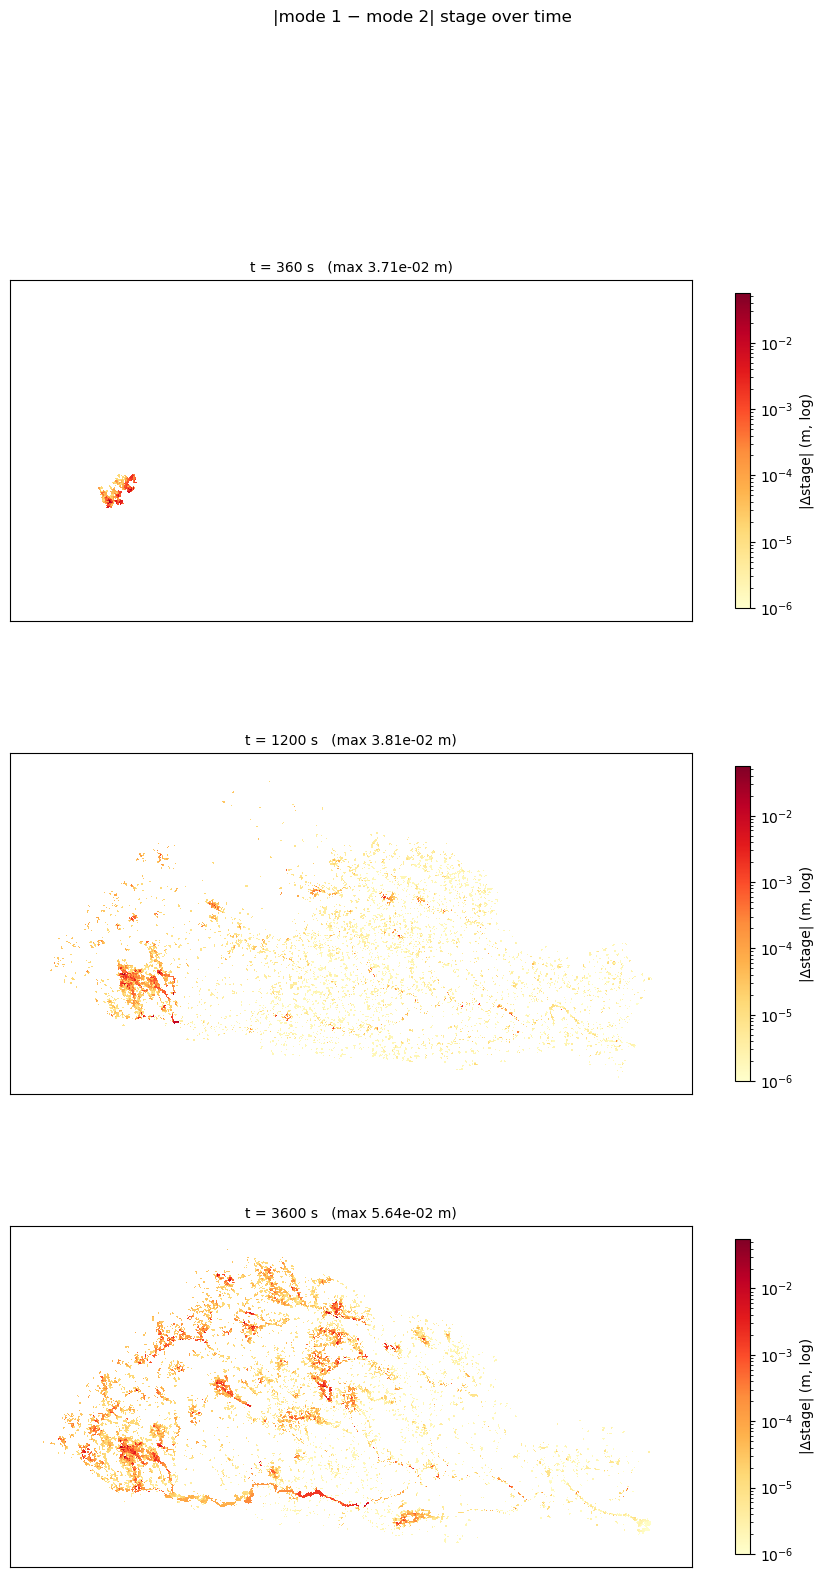

In [6]:
times_to_show = [t for t in (360.0, 1200.0, m1.time[-1]) if t in set(m1.time)]
fig, ax = plt.subplots(len(times_to_show), 1, figsize=(11, 5.8*len(times_to_show)))
fig.set_facecolor('white')
if len(times_to_show) == 1: ax = [ax]
STAGE_FLOOR = 1e-6
vmax = np.abs(m1.stage[-1] - m2.stage[-1])[wet_mask(m1, -1)].max()
norm = LogNorm(vmin=STAGE_FLOOR, vmax=vmax, clip=True)
cmap = _white_cmap('YlOrRd')
for a, t in zip(ax, times_to_show):
    ti = int(np.where(m1.time == t)[0][0])
    v, _ = diff_only(m1, m2, 'stage', ti, STAGE_FLOOR)
    m1.triang.set_mask(None); a.set_facecolor('white')
    tpc = a.tripcolor(m1.triang, facecolors=v, cmap=cmap, norm=norm, shading='flat')
    a.set_aspect('equal'); a.set_xticks([]); a.set_yticks([])
    a.set_title(f't = {t:.0f} s   (max {np.nanmax(v) if np.isfinite(np.nanmax(v)) else 0:.2e} m)', fontsize=10)
    plt.colorbar(tpc, ax=a, shrink=0.8, label='|Δstage| (m, log)')
fig.suptitle('|mode 1 − mode 2| stage over time', y=1.02)

## Takeaways

* Mode 1 and mode 2 solve the same equations; they differ only at **roundoff**, seeded by a
  different flux/update ordering, then amplified chaotically by the wetting/drying dynamics.
* The differences **grow after the rain ramp (t≈360 s)** and end at the **centimetre level**
  on stage (max ~5–8 cm here), with correspondingly small momentum/speed differences.
* Spatially they are **not uniform**: they concentrate in the flooded channels, wet/dry
  fronts and structures — the physically most active regions.
* This is the expected behaviour of a chaotic PDE under two numerically-distinct-but-valid
  solvers, and matches the tolerance seen when swapping GPU back ends. It is **not** a bug in
  either mode; it is the model's own sensitivity made visible.